In [ ]:
!pip install tensorflow

In [ ]:
!pip install numpy pandas matplotlib scikit-learn

In [ ]:
#Load MNIST
from tensorflow.keras.datasets import mnist
import numpy as np
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = mnist.load_data()

2026-04-29 06:29:27.495101: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777444167.691625      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777444167.743720      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777444168.189300      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777444168.189338      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777444168.189340      57 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Preprocessing (28×28 → 32×32 + RGB)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

x_train = tf.image.resize(x_train, (32,32))
x_test = tf.image.resize(x_test, (32,32))

x_train = tf.image.grayscale_to_rgb(x_train)
x_test = tf.image.grayscale_to_rgb(x_test)

x_train = x_train / 255.0
x_test = x_test / 255.0

I0000 00:00:1777444188.643545      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [ ]:
#Imports + EarlyStopping
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [ ]:
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [ ]:
#Base VGG16 model function(WITHOUT BN)
dropouts = [0.2, 0.5, 0.8]
histories_no_bn = {}

def build_vgg16(dropout_rate):
    base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(32,32,3)
    )

    model = Sequential()
    model.add(base)
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))

    # freeze VGG16
    base.trainable = False

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
#Train WITHOUT Batch Normalization
trained_models_no_bn = {}

for d in dropouts:
    print(f"\nTraining VGG16 WITHOUT BN + Dropout = {d}")

    model = build_vgg16(d)

    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=10,
        callbacks=[early_stop],
        verbose=1
    )

    histories_no_bn[d] = history
    trained_models_no_bn[f"no_bn_{d}"] = model


Training VGG16 WITHOUT BN + Dropout = 0.2
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


I0000 00:00:1777444193.739159     135 service.cc:152] XLA service 0x7aaea0010900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777444193.739214     135 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777444194.182992     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


  27/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1990 - loss: 2.2254

I0000 00:00:1777444196.539233     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7723 - loss: 0.7437 - val_accuracy: 0.9441 - val_loss: 0.1813
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9378 - loss: 0.2017 - val_accuracy: 0.9530 - val_loss: 0.1433
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9505 - loss: 0.1558 - val_accuracy: 0.9592 - val_loss: 0.1284
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9565 - loss: 0.1413 - val_accuracy: 0.9567 - val_loss: 0.1271
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9609 - loss: 0.1217 - val_accuracy: 0.9588 - val_loss: 0.1262
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9641 - loss: 0.1110 - val_accuracy: 0.9611 - val_loss: 0.1160
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9668 - loss: 0.1058 - val_accuracy: 0.9680 - val_loss: 0.0985
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9674 - loss: 0.0983 - val

In [ ]:
#VGG16 with Barch Normalization
histories_bn = {}

def build_vgg16_bn(dropout_rate):

    base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(32,32,3)
    )

    model = Sequential()
    model.add(base)

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))

    base.trainable = False

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
#Train WITH Batch Normalization
trained_models_bn = {}

for d in dropouts:
    print(f"\nTraining VGG16 WITH BN + Dropout = {d}")

    model = build_vgg16_bn(d)

    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=10,
        callbacks=[early_stop],
        verbose=1
    )

    histories_bn[d] = history
    trained_models_bn[f"bn_{d}"] = model


Training VGG16 WITH BN + Dropout = 0.2
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8668 - loss: 0.4237 - val_accuracy: 0.9507 - val_loss: 0.1564
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9524 - loss: 0.1506 - val_accuracy: 0.9257 - val_loss: 0.2280
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9600 - loss: 0.1264 - val_accuracy: 0.9495 - val_loss: 0.1538
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9634 - loss: 0.1192 - val_accuracy: 0.9519 - val_loss: 0.1690
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9641 - loss: 0.1128 - val_accuracy: 0.9661 - val_loss: 0.1091
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9650 - loss: 0.1112 - val_accuracy: 0.9613 - val_loss: 0.1243
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9656 - loss: 0.1098 - val_accuracy: 0.9652 - val_loss: 0.1106
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
#Compare LOSS (NO BN vs BN)
df = []

for d in dropouts:
    df.append([
        f"No BN {d}",
        histories_no_bn[d].history['loss'][-1],
        histories_no_bn[d].history['val_loss'][-1],
        histories_no_bn[d].history['accuracy'][-1]
    ])

    df.append([
        f"BN {d}",
        histories_bn[d].history['loss'][-1],
        histories_bn[d].history['val_loss'][-1],
        histories_bn[d].history['accuracy'][-1]
    ])

results = pd.DataFrame(df, columns=["Model", "Loss", "Val Loss", "Accuracy"])
results

,Model,Loss,Val Loss,Accuracy
0,No BN 0.2,0.088868,0.091408,0.971375
1,BN 0.2,0.100726,0.108171,0.968083
2,No BN 0.5,0.138394,0.102598,0.956479
3,BN 0.5,0.142305,0.107425,0.955979
4,No BN 0.8,0.436417,0.141482,0.844521
5,BN 0.8,0.299611,0.123370,0.906979


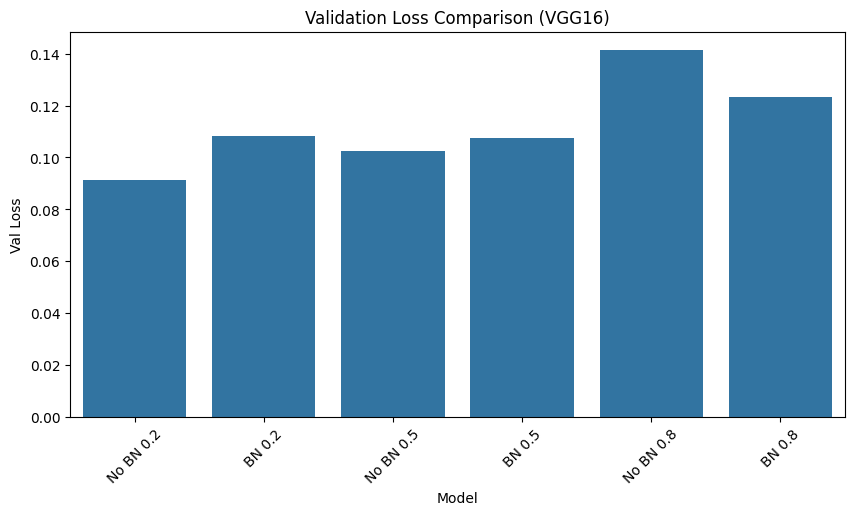

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=results, x="Model", y="Val Loss")
plt.xticks(rotation=45)
plt.title("Validation Loss Comparison (VGG16)")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_model_comparison(results_dict, title="Model Performance Analysis"):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=16)

    #LOSS PLOT
    for name, history in results_dict.items():
        epochs = range(1, len(history.history['loss']) + 1)

        ax1.plot(epochs, history.history['loss'], label=f'{name} - Train')
        ax1.plot(epochs, history.history['val_loss'], linestyle='--', label=f'{name} - Val')

    ax1.set_title('Loss Comparison')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    #ACCURACY PLOT
    for name, history in results_dict.items():
        epochs = range(1, len(history.history['accuracy']) + 1)

        ax2.plot(epochs, history.history['accuracy'], label=f'{name} - Train')
        ax2.plot(epochs, history.history['val_accuracy'], linestyle='--', label=f'{name} - Val')

    ax2.set_title('Accuracy Comparison')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

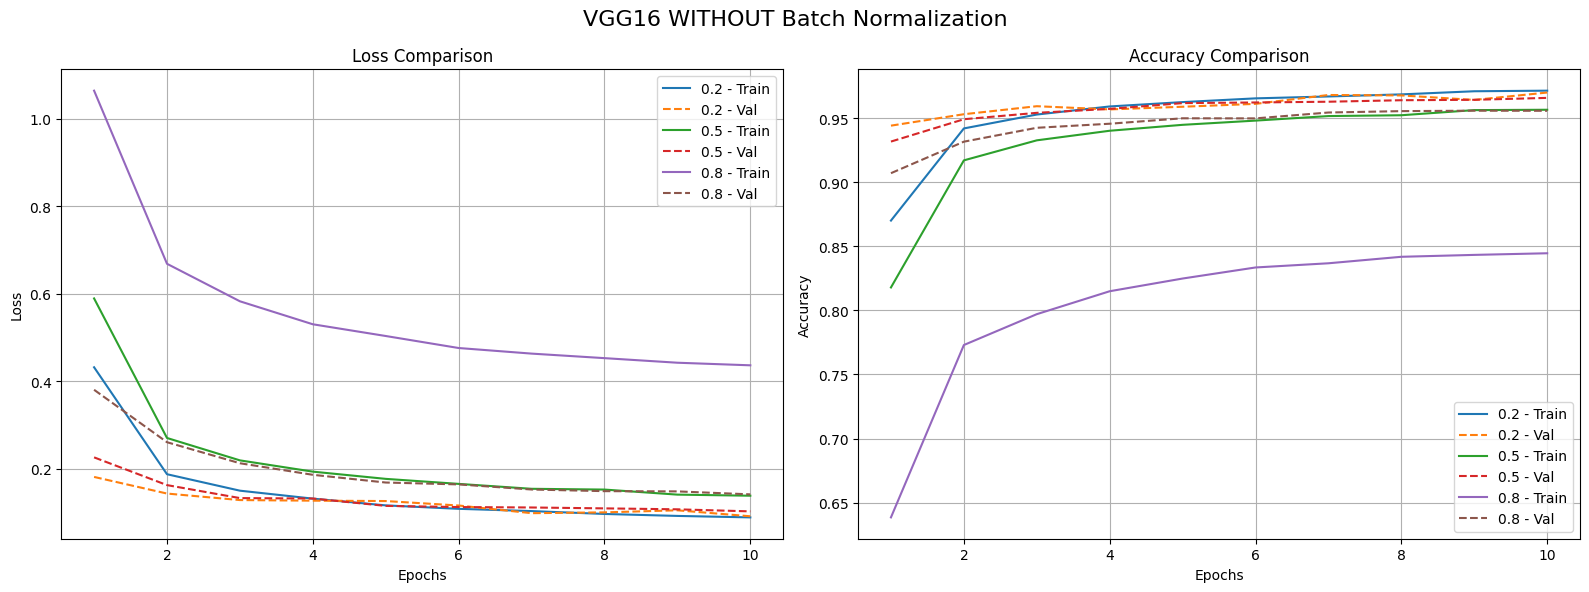

In [ ]:
#WITHOUT BN
plot_model_comparison(histories_no_bn, "VGG16 WITHOUT Batch Normalization")

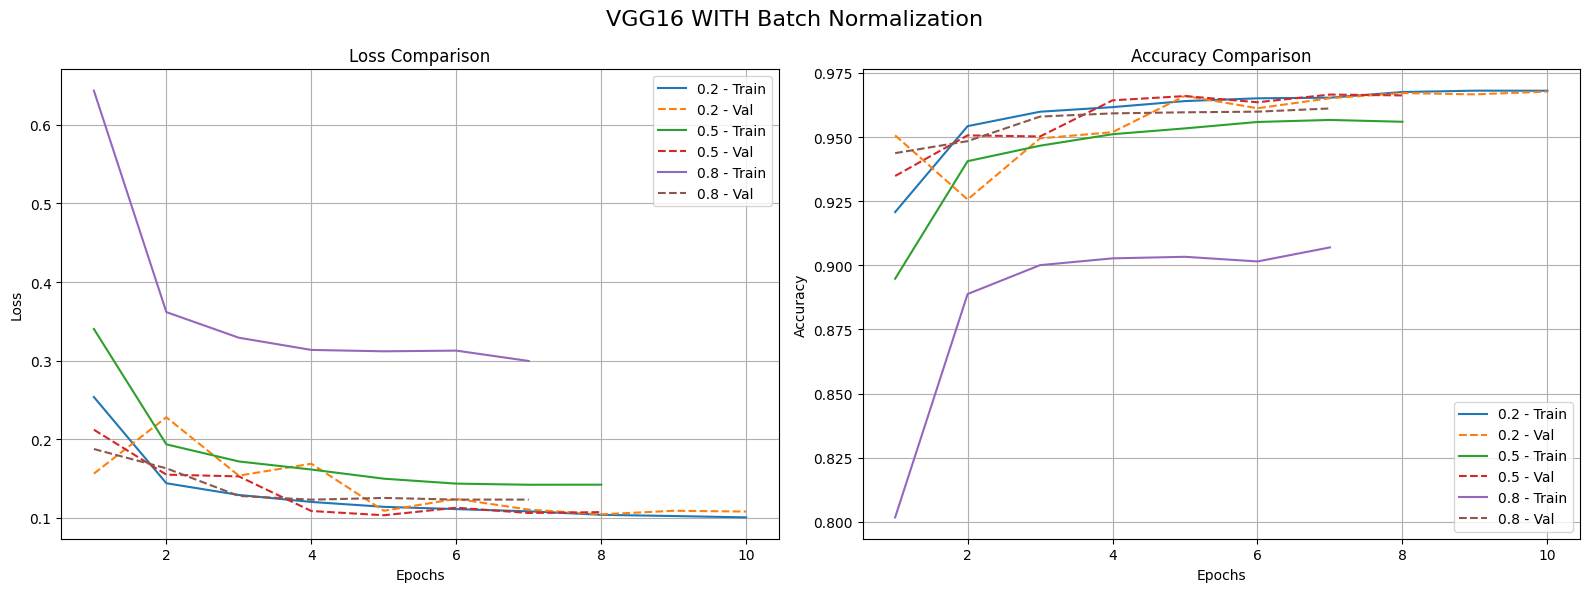

In [ ]:
#WITH BN
plot_model_comparison(histories_bn, "VGG16 WITH Batch Normalization")

In [ ]:
#Model Evaluation(Accuracy + F1)
from sklearn.metrics import accuracy_score, f1_score

def evaluate_models(model_dict, x_test, y_test):
    results = {}

    for name, model in model_dict.items():
        print(f"\nEvaluating: {name}")

        y_pred = model.predict(x_test).argmax(axis=1)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        print("Accuracy:", acc)
        print("F1 Score:", f1)

        results[name] = {
            "accuracy": acc,
            "f1_score": f1
        }

    return results


dropout_eval = evaluate_models(trained_models_no_bn, x_test, y_test)
bn_eval = evaluate_models(trained_models_bn, x_test, y_test)


Evaluating: no_bn_0.2
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Accuracy: 0.9751
F1 Score: 0.9750997201898058

Evaluating: no_bn_0.5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.9696
F1 Score: 0.969602693645097

Evaluating: no_bn_0.8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.9588
F1 Score: 0.9586970724277649

Evaluating: bn_0.2
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.9704
F1 Score: 0.9703584292798625

Evaluating: bn_0.5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.9699
F1 Score: 0.9699116122100974

Evaluating: bn_0.8
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.9634
F1 Score: 0.9633535141309014


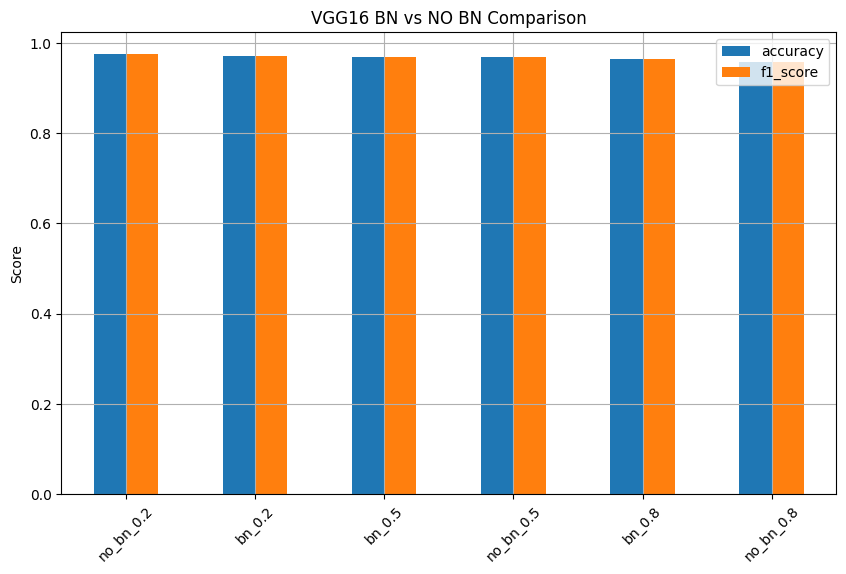

In [ ]:
import matplotlib.pyplot as plt

df_results[['accuracy', 'f1_score']].plot(kind='bar', figsize=(10,6))

plt.title("VGG16 BN vs NO BN Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Best Model: no_bn_0.2
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


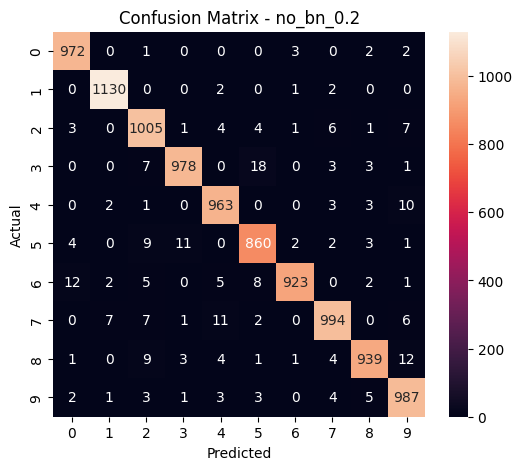

In [ ]:
#Best Model + Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_model_name = df_results.index[0]
print("Best Model:", best_model_name)

if best_model_name in trained_models_no_bn:
    best_model = trained_models_no_bn[best_model_name]
else:
    best_model = trained_models_bn[best_model_name]

y_pred = best_model.predict(x_test).argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

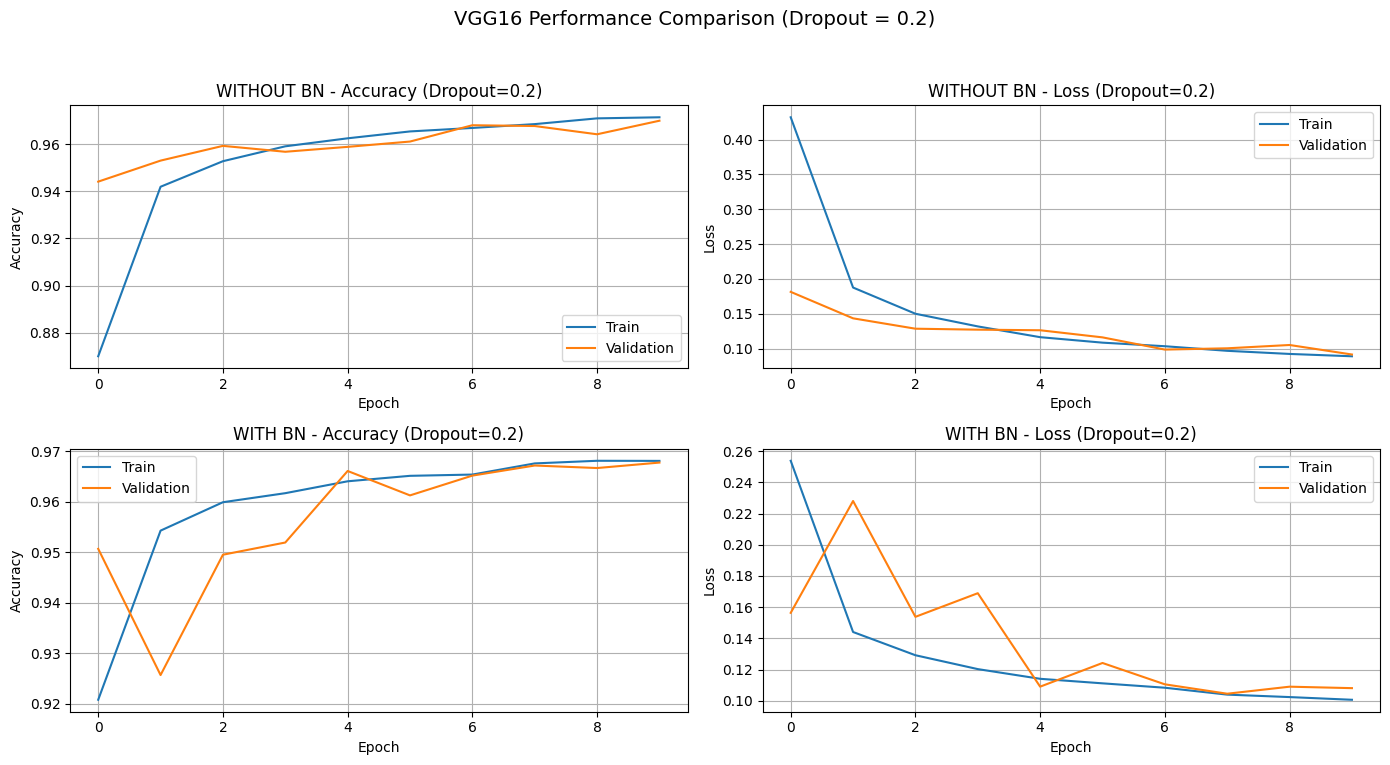

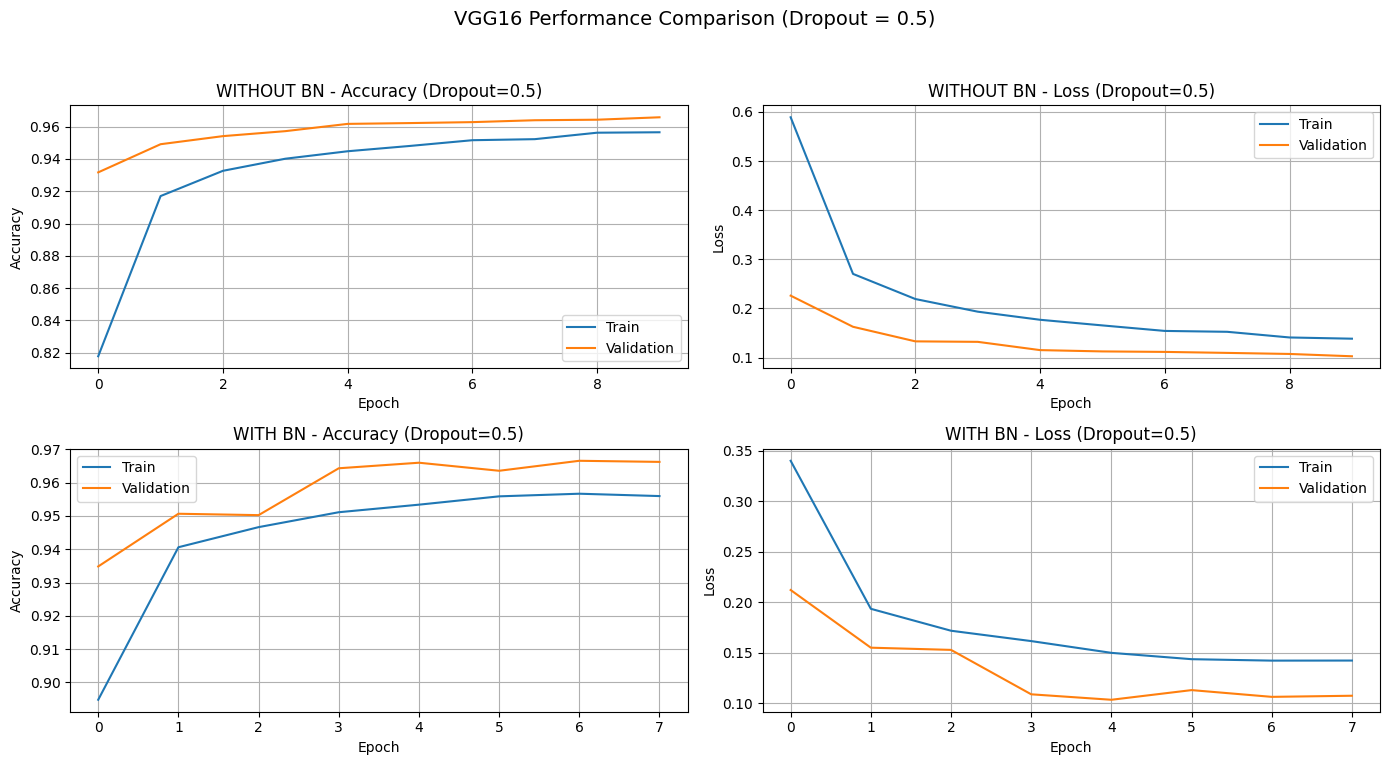

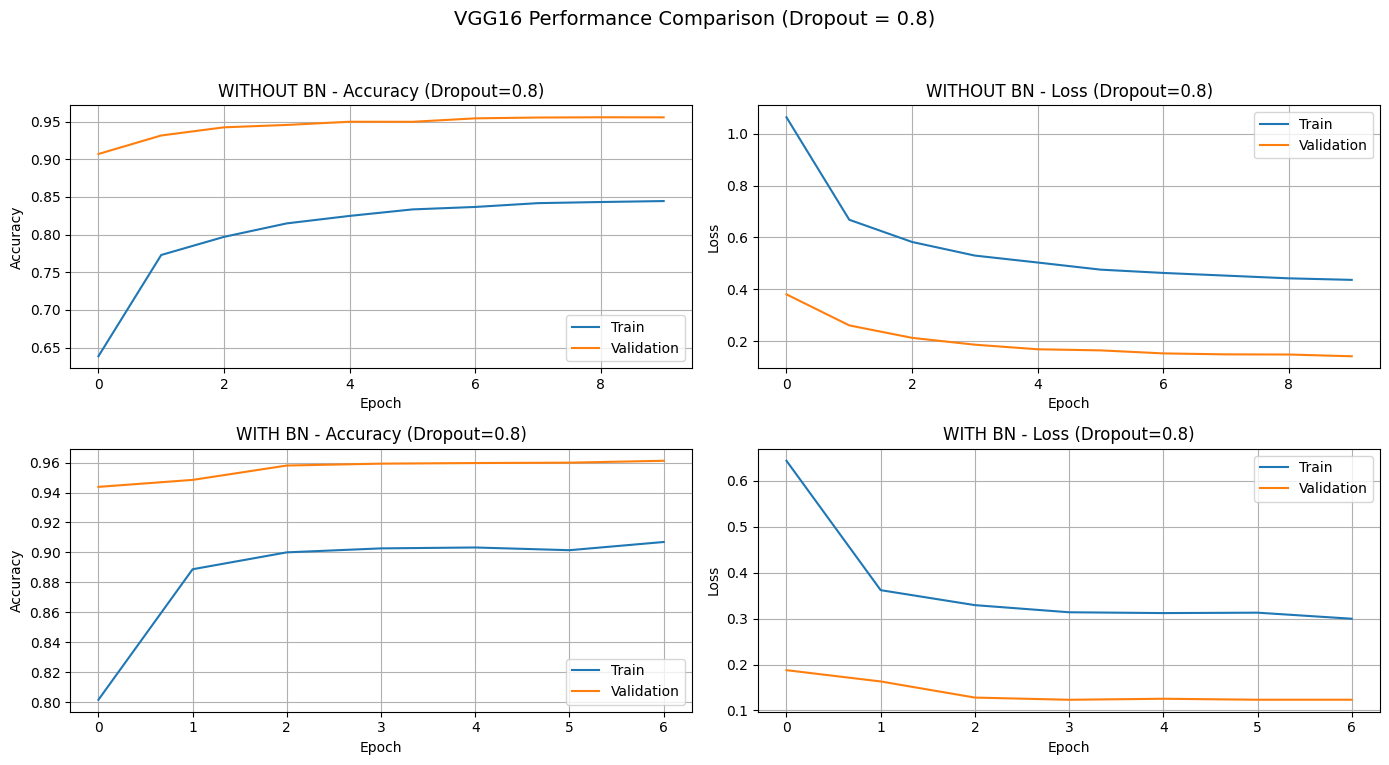

In [ ]:
import matplotlib.pyplot as plt

for d in dropouts:

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # ================= WITHOUT BATCH NORMALIZATION =================
    h_no_bn = histories_no_bn[d]

    # Accuracy
    axes[0, 0].plot(h_no_bn.history['accuracy'], label='Train')
    axes[0, 0].plot(h_no_bn.history['val_accuracy'], label='Validation')
    axes[0, 0].set_title(f'WITHOUT BN - Accuracy (Dropout={d})')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Loss
    axes[0, 1].plot(h_no_bn.history['loss'], label='Train')
    axes[0, 1].plot(h_no_bn.history['val_loss'], label='Validation')
    axes[0, 1].set_title(f'WITHOUT BN - Loss (Dropout={d})')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # ================= WITH BATCH NORMALIZATION =================
    h_bn = histories_bn[d]

    # Accuracy
    axes[1, 0].plot(h_bn.history['accuracy'], label='Train')
    axes[1, 0].plot(h_bn.history['val_accuracy'], label='Validation')
    axes[1, 0].set_title(f'WITH BN - Accuracy (Dropout={d})')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Loss
    axes[1, 1].plot(h_bn.history['loss'], label='Train')
    axes[1, 1].plot(h_bn.history['val_loss'], label='Validation')
    axes[1, 1].set_title(f'WITH BN - Loss (Dropout={d})')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.suptitle(f'VGG16 Performance Comparison (Dropout = {d})', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
